In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set seed 
np.random.seed(42)

In [2]:
import matplotlib as mpl
import seaborn as sns

sns.set_theme(
    style="whitegrid",
    context="talk",   # important: larger defaults than "notebook"
    rc={
        # Grid: very light, behind data
        "grid.color": "#E5E5E5",
        "grid.linewidth": 0.8,
        "grid.alpha": 1.0,
        "axes.axisbelow": True,

        # Background
        "axes.facecolor": "white",
        "figure.facecolor": "white",

        # Axes (Prism-like)
        "axes.linewidth": 1.8,
        "axes.edgecolor": "black",
        "axes.spines.top": False,
        "axes.spines.right": False,

        # Fonts (slide readable)
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "font.size": 16,
        "axes.labelsize": 18,
        "axes.titlesize": 20,
        "legend.fontsize": 14,

        # Ticks: explicitly outside
        "xtick.direction": "out",
        "ytick.direction": "out",
        "xtick.major.width": 1.8,
        "ytick.major.width": 1.8,
        "xtick.major.size": 7,
        "ytick.major.size": 7,
        "xtick.minor.size": 4,
        "ytick.minor.size": 4,
        "xtick.color": "black",
        "ytick.color": "black",

        # Lines & error bars
        "lines.linewidth": 2.5,
        "lines.markersize": 8,
        "errorbar.capsize": 5,
    }
)


# 1. Handling the data

In [3]:
df = pd.read_csv('data/forPython_try2.csv', sep = ';', decimal = ',')
df.head()

,Time,Sample,cDC1,Macrophages,cDC2,pDCs,MDP,Monocytes,HSC,Cells negative for all markers,DCPs,B cells,"NK cells, Eosinophils, granulocytes, neutrophils",Others
0,Before thawing,US,0.0000,0.0000,0.00000,0.0000,0.00000,0.0000,0.00000,0.9940,0.00,0.0000,0.000,0.00600
1,Before thawing - Pre-sort,cDC1 no change,0.0099,0.0546,0.02208,0.0195,0.00022,0.0841,0.00066,0.0906,0.21,0.0723,0.157,0.27904
2,Before thawing - Pre-sort,cDC1 change everyday,0.0099,0.0546,0.02208,0.0195,0.00022,0.0841,0.00066,0.0906,0.21,0.0723,0.157,0.27904
3,Before thawing - Pre-sort,cDC1 change 1 of 2,0.0099,0.0546,0.02208,0.0195,0.00022,0.0841,0.00066,0.0906,0.21,0.0723,0.157,0.27904
4,Before thawing - Pre-sort,HSC no change,0.0099,0.0546,0.02208,0.0195,0.00022,0.0841,0.00066,0.0906,0.21,0.0723,0.157,0.27904


In [4]:
# Drop columns where sample is US 
df = df[df['Sample'] != 'US']
df.head()

,Time,Sample,cDC1,Macrophages,cDC2,pDCs,MDP,Monocytes,HSC,Cells negative for all markers,DCPs,B cells,"NK cells, Eosinophils, granulocytes, neutrophils",Others
1,Before thawing - Pre-sort,cDC1 no change,0.0099,0.0546,0.02208,0.0195,0.00022,0.0841,0.00066,0.0906,0.21,0.0723,0.157,0.27904
2,Before thawing - Pre-sort,cDC1 change everyday,0.0099,0.0546,0.02208,0.0195,0.00022,0.0841,0.00066,0.0906,0.21,0.0723,0.157,0.27904
3,Before thawing - Pre-sort,cDC1 change 1 of 2,0.0099,0.0546,0.02208,0.0195,0.00022,0.0841,0.00066,0.0906,0.21,0.0723,0.157,0.27904
4,Before thawing - Pre-sort,HSC no change,0.0099,0.0546,0.02208,0.0195,0.00022,0.0841,0.00066,0.0906,0.21,0.0723,0.157,0.27904
5,Before thawing - Pre-sort,HSC change everyday,0.0099,0.0546,0.02208,0.0195,0.00022,0.0841,0.00066,0.0906,0.21,0.0723,0.157,0.27904


In [5]:
df[df["Time"] == "Day 1"]

,Time,Sample,cDC1,Macrophages,cDC2,pDCs,MDP,Monocytes,HSC,Cells negative for all markers,DCPs,B cells,"NK cells, Eosinophils, granulocytes, neutrophils",Others
21,Day 1,cDC1 no change,0.0057,0.1455,0.00460,0.00110,0.0,0.0732,0.0,0.0378,0.0709,0.00340,0.0011,0.65670
22,Day 1,cDC1 change everyday,0.0066,0.1458,0.00410,0.00100,0.0,0.0818,0.0,0.0493,0.0838,0.00200,0.0056,0.62000
23,Day 1,cDC1 change 1 of 2,0.0057,0.1455,0.00460,0.00110,0.0,0.0732,0.0,0.0378,0.0709,0.00340,0.0011,0.65670
24,Day 1,HSC no change,0.0024,0.0742,0.00079,0.00079,0.0,0.0940,0.0,0.0521,0.0711,0.00079,0.0032,0.70063
25,Day 1,HSC change everyday,0.0024,0.0742,0.00079,0.00079,0.0,0.0940,0.0,0.0521,0.0711,0.00079,0.0032,0.70063
26,Day 1,HSC change 1 of 2,0.0050,0.0818,0.00000,0.00130,0.0,0.1370,0.0,0.0491,0.0957,0.00063,0.0038,0.62567


In [6]:
# Columns you want to keep fixed at the front
meta_cols = ["Time", "Sample"]

# Select numeric columns only
num_cols = df.select_dtypes(include="number").columns

# Compute mean of each numeric column and sort descending
sorted_num_cols = (
    df[num_cols]
    .mean()
    .sort_values(ascending=False)
    .index
)

# Reorder dataframe
df_sorted = df[meta_cols + list(sorted_num_cols)]
df=df_sorted

# 2. Preprocessing

In [7]:
def split_by_day (dataframe):
    sample_days = {}
    for day in dataframe["Time"].unique():
        sample_days[day] = dataframe[dataframe["Time"] == day]
    return sample_days

In [8]:
def split_by_sample(df):
    sample_dict = {}
    for sample_name in df["Sample"].unique():
        sample_dict[sample_name] = df[df["Sample"] == sample_name]

    return sample_dict


In [9]:
results_by_day = split_by_day(df)

## Cell type proportions

In [10]:
results_by_day

{'Before thawing - Pre-sort':                         Time                Sample  \
 1  Before thawing - Pre-sort        cDC1 no change   
 2  Before thawing - Pre-sort  cDC1 change everyday   
 3  Before thawing - Pre-sort    cDC1 change 1 of 2   
 4  Before thawing - Pre-sort         HSC no change   
 5  Before thawing - Pre-sort   HSC change everyday   
 6  Before thawing - Pre-sort    HSC change 1 of 2    
 
    Cells negative for all markers  DCPs  Others   \
 1                          0.0906  0.21  0.27904   
 2                          0.0906  0.21  0.27904   
 3                          0.0906  0.21  0.27904   
 4                          0.0906  0.21  0.27904   
 5                          0.0906  0.21  0.27904   
 6                          0.0906  0.21  0.27904   
 
    NK cells, Eosinophils, granulocytes, neutrophils  Monocytes  Macrophages  \
 1                                             0.157     0.0841       0.0546   
 2                                             0.15

In [11]:
before_thawing_pre_sort_df = results_by_day["Before thawing - Pre-sort"].copy()
after_thawing_post_sort_df = results_by_day["Before thawing - Sorted"].copy()
day0_df = results_by_day["Day 0"].copy()

# Keep only the first lines of each dataframe
before_thawing_pre_sort_df = before_thawing_pre_sort_df.iloc[:1]
after_thawing_post_sort_df = after_thawing_post_sort_df.iloc[:1]
day0_df = day0_df.iloc[:1]

# Change the name of the Time in that column so they are in the same plot
before_thawing_pre_sort_df["Time"] = "Before and after thawing"
after_thawing_post_sort_df["Time"] = "Before and after thawing"
day0_df["Time"] = "Before and after thawing"

# Change the name of the Sample in that column 
before_thawing_pre_sort_df["Sample"] = "Pre-sort"
after_thawing_post_sort_df["Sample"] = "Post-sort"
day0_df["Sample"] = "After thawing"

first_days_df = pd.concat([before_thawing_pre_sort_df, after_thawing_post_sort_df, day0_df])
first_days_df

,Time,Sample,Cells negative for all markers,DCPs,Others,"NK cells, Eosinophils, granulocytes, neutrophils",Monocytes,Macrophages,cDC2,B cells,pDCs,cDC1,MDP,HSC
1,Before and after thawing,Pre-sort,0.0906,0.210,0.27904,0.1570,0.08410,0.0546,0.02208,0.07230,0.0195,0.0099,0.00022,0.00066
7,Before and after thawing,Post-sort,0.6650,0.303,0.02240,0.0016,0.00025,0.0000,0.00000,0.00055,0.0001,0.0024,0.00000,0.00470
13,Before and after thawing,After thawing,0.0512,0.615,0.19740,0.0100,0.06920,0.0340,0.01640,0.00120,0.0008,0.0020,0.00280,0.00000


In [12]:
cols = list(first_days_df.columns)

# Define the two columns to swap
col_dcp = "DCPs"
col_neg = "Cells negative for all markers"

# Remove them from the list
cols.remove(col_dcp)
cols.remove(col_neg)

# Reinsert in the desired order
neg_idx = cols.index("Sample") + 1   # or any anchor you prefer
cols.insert(neg_idx, col_dcp)
cols.insert(neg_idx + 1, col_neg)

# Reorder dataframe
first_days_df = first_days_df[cols]
first_days_df

,Time,Sample,DCPs,Cells negative for all markers,Others,"NK cells, Eosinophils, granulocytes, neutrophils",Monocytes,Macrophages,cDC2,B cells,pDCs,cDC1,MDP,HSC
1,Before and after thawing,Pre-sort,0.210,0.0906,0.27904,0.1570,0.08410,0.0546,0.02208,0.07230,0.0195,0.0099,0.00022,0.00066
7,Before and after thawing,Post-sort,0.303,0.6650,0.02240,0.0016,0.00025,0.0000,0.00000,0.00055,0.0001,0.0024,0.00000,0.00470
13,Before and after thawing,After thawing,0.615,0.0512,0.19740,0.0100,0.06920,0.0340,0.01640,0.00120,0.0008,0.0020,0.00280,0.00000


In [13]:
# Add first_days_df to results_by_day
results_by_day["First days"] = first_days_df
results_by_day["First days duplicate test"] = first_days_df

# Delete "Before thawing - Pre-sort", "Before thawing - Sorted", "Day 0" from results_by_day
del results_by_day["Before thawing - Pre-sort"]
del results_by_day["Before thawing - Sorted"]
del results_by_day["Day 0"]

# Move First days to the beginning of the dictionary
results_by_day = {"Before Thawing and Day 0": results_by_day["First days"], **{k: v for k, v in results_by_day.items() if k != "First days"}}

In [14]:
results_by_day

{'Before Thawing and Day 0':                         Time         Sample   DCPs  \
 1   Before and after thawing       Pre-sort  0.210   
 7   Before and after thawing      Post-sort  0.303   
 13  Before and after thawing  After thawing  0.615   
 
     Cells negative for all markers  Others   \
 1                           0.0906  0.27904   
 7                           0.6650  0.02240   
 13                          0.0512  0.19740   
 
     NK cells, Eosinophils, granulocytes, neutrophils  Monocytes  Macrophages  \
 1                                             0.1570    0.08410       0.0546   
 7                                             0.0016    0.00025       0.0000   
 13                                            0.0100    0.06920       0.0340   
 
        cDC2  B cells    pDCs    cDC1      MDP      HSC  
 1   0.02208  0.07230  0.0195  0.0099  0.00022  0.00066  
 7   0.00000  0.00055  0.0001  0.0024  0.00000  0.00470  
 13  0.01640  0.00120  0.0008  0.0020  0.00280  0.00000 

## DCP proportions

In [15]:
sns.color_palette("Spectral", n_colors=12)

[(0.7803152633602461, 0.182160707420223, 0.2968089196462899),
 (0.8996539792387543, 0.340715109573241, 0.2848904267589389),
 (0.9679354094579008, 0.5074202229911572, 0.2996539792387543),
 (0.9923875432525952, 0.6938869665513263, 0.3900807381776239),
 (0.9954632833525567, 0.8476739715494039, 0.519261822376009),
 (0.9985390234525182, 0.9547097270280661, 0.6730488273740869),
 (0.9634755863129566, 0.9853902345251826, 0.6920415224913495),
 (0.8656670511341794, 0.9460207612456749, 0.6034602076124567),
 (0.6841983852364477, 0.8722029988465976, 0.6403690888119954),
 (0.48489042675893923, 0.7940023068050751, 0.6458285274894272),
 (0.30403690888119955, 0.6537485582468281, 0.6913494809688582),
 (0.24006151480199922, 0.47635524798154555, 0.7141868512110727)]

In [16]:
# Keep only the DCP proportions
dcp_proportions = df.pivot(index='Time', columns='Sample', values='DCPs')
dcp_proportions

Sample,HSC change 1 of 2,HSC change everyday,HSC no change,cDC1 change 1 of 2,cDC1 change everyday,cDC1 no change
Time,,,,,,
Before thawing - Pre-sort,0.2100,0.2100,0.2100,0.2100,0.2100,0.2100
Before thawing - Sorted,0.3030,0.3030,0.3030,0.3030,0.3030,0.3030
Day 0,0.6150,0.6150,0.6150,0.6150,0.6150,0.6150
Day 1,0.0957,0.0711,0.0711,0.0709,0.0838,0.0709
Day 2,0.3270,0.2440,0.2710,0.2450,0.1860,0.2120
Day 3,0.3540,0.2810,0.3270,0.3540,0.4010,0.3200
Day 4,0.1680,0.1800,0.1450,0.1810,0.1810,0.1530
Day 5,0.0432,0.0431,0.0676,0.0392,0.0738,0.0482
Day 6,0.0145,0.0249,0.0179,0.0134,0.0247,0.0146


In [17]:
categorical_10 = [
    "#3a5a8c",  # navy
    "#4a8bb8",  # blue
    "#5fb7b4",  # teal
    "#8fe0d1",  # aqua
    "#f2e85c",  # yellow
    "#f6a55f",  # orange
    "#f07a63",  # coral red
    "#d07a93",  # rose
    "#a17ad9",  # purple
    "#8a78b8"   # soft purple
]

palette = [
    "#FF6F61",  # Coral
    "#0B2545",  # Deep Navy
    "#4FA3B8",  # Steel Blue
    "#9EDAE5",  # Sky Blue
    "#D97706",  # Burnt Orange
    "#FFB4A2",  # Soft Peach
    "#F2C94C",  # Golden Yellow
    "#7FB3A1",  # Sage Green
    "#0887A0",  # Teal Blue
    "#a17ad9",  # purple
    "#7A6C9D",  # Muted Purple
    "#d07a93" # rose
]


# 3. Figures

## Proportion of cell types

In [18]:
categorical_12 = [
    "#3a5a8c",  # navy
    "#4a8bb8",  # blue
    "#5fb7b4",  # teal
    "#8fe0d1",  # aqua
    "#f2e85c",  # yellow
    "#f6a55f",  # orange
    "#f07a63",  # coral red
    "#f46310",  # soft purple
    "#d07a93",  # rose
    "#a17ad9",  # purple
    "#8a78b8",  # soft purple
    "#573c9a"   # soft purple
]

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_celltype_composition_6panels(df, time_col="Time", sample_col="Sample", ncols=3):
    # Cell-type columns = everything except identifiers
    id_cols = [time_col, sample_col]
    cell_cols = [c for c in df.columns if c not in id_cols]

    # Take the first 6 timepoints
    times = pd.unique(df[time_col])[:6]

    n_panels = len(times)
    nrows = int(np.ceil(n_panels / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(6 * ncols, 4.5 * nrows),
        sharey=True,
        sharex=True
    )
    axes = np.atleast_1d(axes).ravel()

    # Seaborn color palette for cell types
    colors = sns.color_palette(categorical_12)
    #colors = sns.color_palette("husl", n_colors=len(cell_cols))
    color_map = dict(zip(cell_cols, colors))

    for ax, t in zip(axes, times):
        sub = df[df[time_col] == t].copy()

        # Preserve sample order
        sample_order = pd.unique(sub[sample_col])
        sub[sample_col] = pd.Categorical(
            sub[sample_col], categories=sample_order, ordered=True
        )
        sub = sub.sort_values(sample_col)

        x = np.arange(len(sub))
        bottoms = np.zeros(len(sub))

        for c in cell_cols:
            ax.bar(
                x,
                sub[c].values,
                bottom=bottoms,
                color=color_map[c],
                width=0.85,
                label=c
            )
            bottoms += sub[c].values

        ax.set_title(str(t))
        ax.set_xticks(x)
        ax.set_xticklabels(
            sub[sample_col].astype(str),
            rotation=45,
            ha="right"
        )
        ax.set_ylim(0, 1)
        ax.set_ylabel("Proportion")

    # Turn off unused axes
    for ax in axes[len(times):]:
        ax.axis("off")
    
    # ---- Figure title ----
    fig.suptitle(
        "Cell-type proportions across timepoints",
        fontsize=18,
        fontweight="bold",
        y=0.93
    )

    fig.tight_layout(rect=[0, 0.05, 0.85, 0.95])

    # ---- Figure-level legend at bottom ----
    handles, labels = axes[-1].get_legend_handles_labels()

    # Create a global legend at the bottom with styling
    legend = fig.legend(
        handles,
        labels,
        loc='lower right',
        bbox_to_anchor=(0.45, -0.1),
        ncol=4,
        frameon=True,
        fontsize=12,
    )

    # Style the legend frame
    frame = legend.get_frame()
    #frame.set_edgecolor("black")       # Border color
    frame.set_linewidth(1.2)           # Border thickness
    frame.set_facecolor("white")       # Background color
    frame.set_alpha(0.95)              # Slight transparency
    frame.set_boxstyle("round,pad=0.4")  # Rounded corners + internal padding

    return fig, axes


# Usage:
# fig, axes = plot_celltype_composition_6panels(df)
# plt.show()


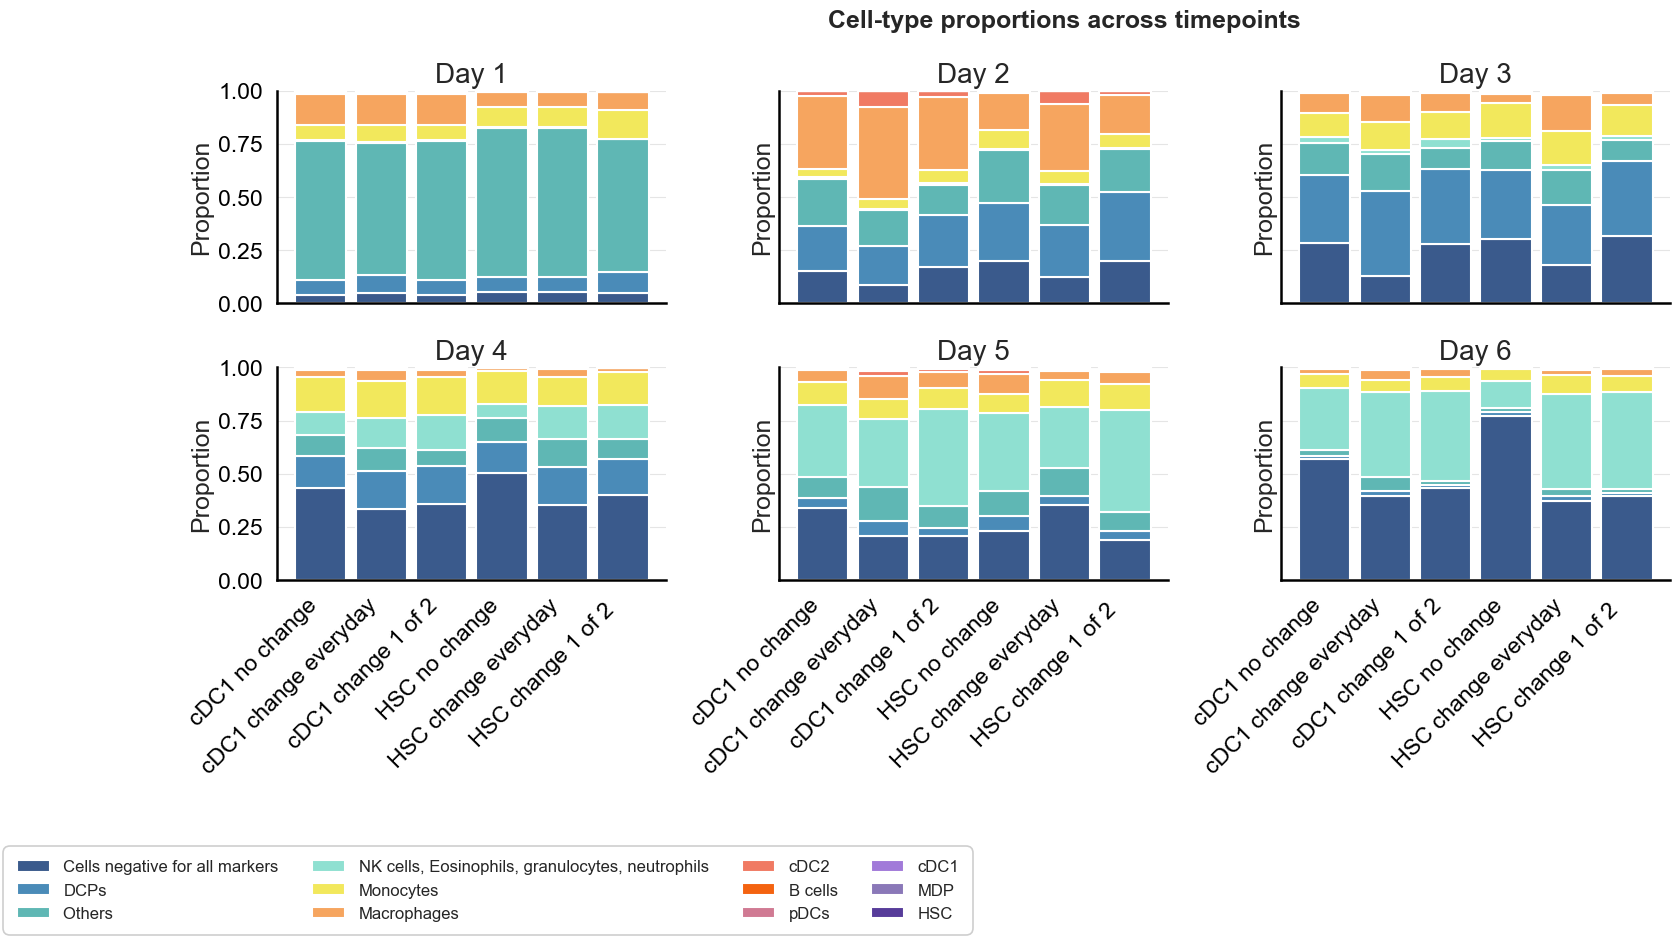

In [20]:
fig, axes = plot_celltype_composition_6panels(df[18:])
plt.savefig("Figures/assessing_viability/celltype_composition_6panels.png", bbox_inches='tight')
plt.show()

/var/folders/sg/4rtgrsm92ml0l4zxhf4g6m6c0000gn/T/ipykernel_91436/2765554346.py:47: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 0.85, 1])


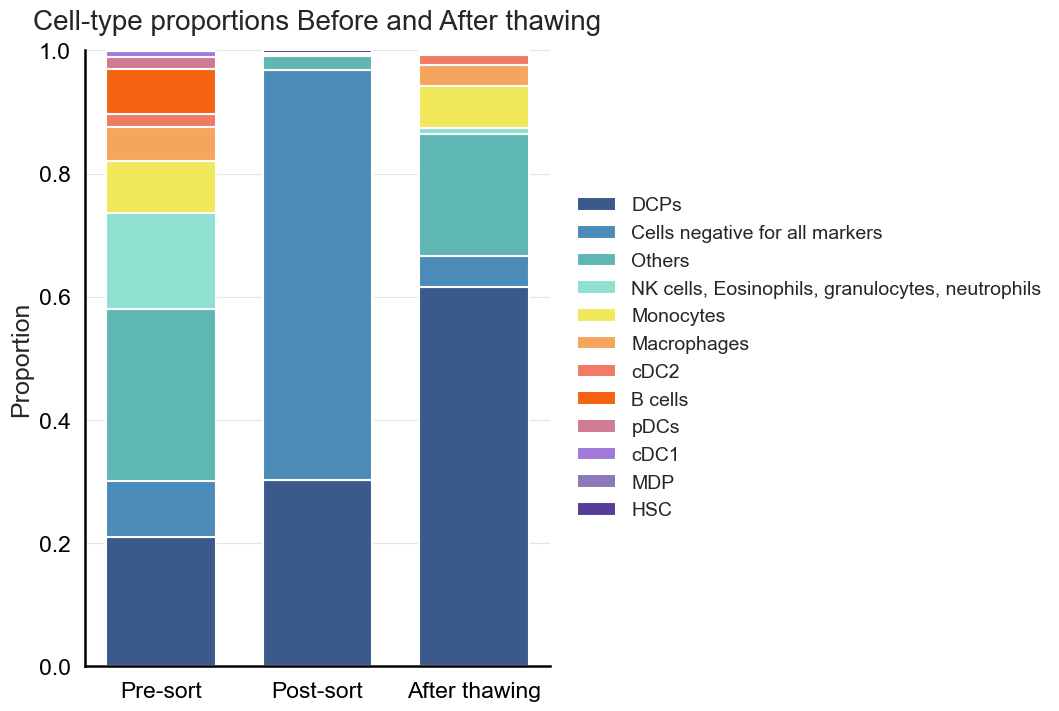

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Prepare data ----
meta_cols = ["Time", "Sample"]
cell_cols = [c for c in first_days_df.columns if c not in meta_cols]

# X positions
x = np.arange(len(first_days_df))
labels = first_days_df["Sample"]

# Colors
colors = sns.color_palette(categorical_12)
color_map = dict(zip(cell_cols, colors))

# ---- Plot ----
fig, ax = plt.subplots(figsize=(6, 8))

bottoms = np.zeros(len(first_days_df))
for c in cell_cols:
    ax.bar(
        x,
        first_days_df[c].values,
        bottom=bottoms,
        color=color_map[c],
        width=0.7,
        label=c
    )
    bottoms += first_days_df[c].values

# ---- Formatting ----
ax.set_ylim(0, 1)
ax.set_ylabel("Proportion")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_title("Cell-type proportions Before and After thawing", pad=15)

# ---- Legend: outside, right ----
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),  # push legend just outside axes
    frameon=False
)

# Keep axes size almost unchanged
plt.tight_layout(rect=[0, 0, 0.85, 1])

plt.savefig(
    "Figures/assessing_viability/cell_type_proportions_before_after_thawing.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## DCP proportions

In [22]:
prism_colors = [
    "#000000",  # black
    "#E41A1C",  # red
    "#377EB8",  # blue
    "#4DAF4A",  # green
    "#984EA3",  # purple
    "#FF7F00",  # orange
]


In [23]:
palette_okabe_ito = [
    "#E69F00",  # orange
    "#56B4E9",  # sky blue
    "#009E73",  # bluish green
    "#0072B2",  # blue
    "#D55E00",  # vermillion
    "#CC79A7",  # reddish purple
]


In [24]:
palette_graphpad_floral = [
    "#F2B6C1",  # soft pink
    "#C7A4D8",  # lavender
    "#9ECBEA",  # light blue
    "#9AD9C7",  # mint green
    "#BEE3A2",  # light green
    "#F6E3A1",  # pale yellow
    "#F5B48A",  # peach
    "#D9D9D9",  # light gray
]

In [25]:
categorical_6 = [
    "#3a5a8c",  # navy
    #"#4a8bb8",  # blue
    "#5fb7b4",  # teal
    # "#8fe0d1",  # aqua
    "#02d722",  # yellow
    "#f6a55f",  # orange
    "#f07a63",  # coral red
    #"#d07a93",  # rose
    "#a17ad9",  # purple
    # "#8a78b8"   # soft purple
]

In [26]:
#sns.set_palette(categorical_6)
sns.set_palette(palette_okabe_ito)

In [27]:
dcp_proportions_06 = dcp_proportions[2:]

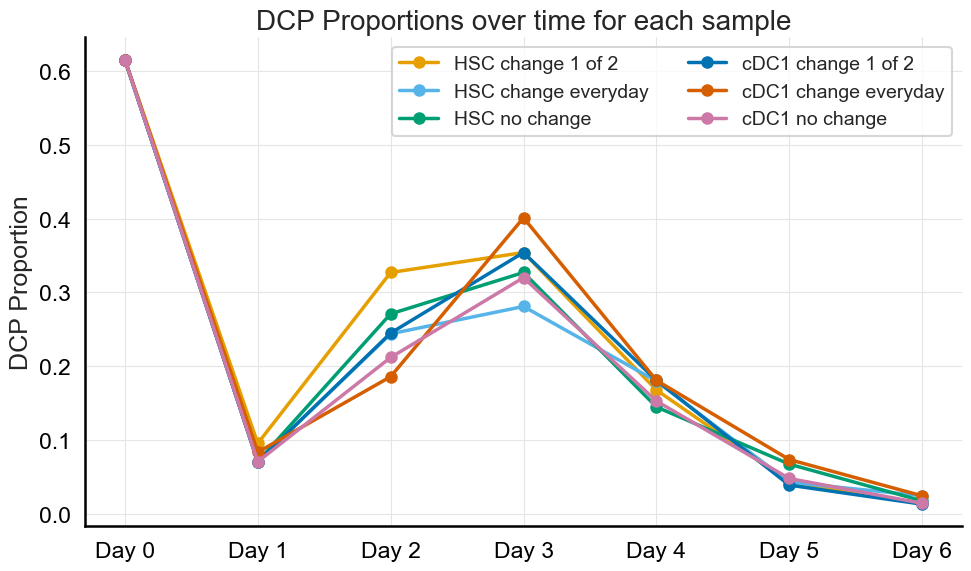

In [28]:
# Plotting DCP proportions with line plot
plt.figure(figsize=(10, 6))

for sample in dcp_proportions_06.columns:
    plt.plot(dcp_proportions_06.index, dcp_proportions_06[sample], marker='o', label=sample)  

plt.title('DCP Proportions over time for each sample')
plt.ylabel('DCP Proportion')
#plt.xticks(rotation=45, ha='right')
plt.legend(title="", frameon=True, ncol=2)
plt.tight_layout()
plt.savefig('Figures/assessing_viability/DCP_proportions_line_plot.png', dpi=300, bbox_inches='tight');

In [29]:
dcp_proportions

Sample,HSC change 1 of 2,HSC change everyday,HSC no change,cDC1 change 1 of 2,cDC1 change everyday,cDC1 no change
Time,,,,,,
Before thawing - Pre-sort,0.2100,0.2100,0.2100,0.2100,0.2100,0.2100
Before thawing - Sorted,0.3030,0.3030,0.3030,0.3030,0.3030,0.3030
Day 0,0.6150,0.6150,0.6150,0.6150,0.6150,0.6150
Day 1,0.0957,0.0711,0.0711,0.0709,0.0838,0.0709
Day 2,0.3270,0.2440,0.2710,0.2450,0.1860,0.2120
Day 3,0.3540,0.2810,0.3270,0.3540,0.4010,0.3200
Day 4,0.1680,0.1800,0.1450,0.1810,0.1810,0.1530
Day 5,0.0432,0.0431,0.0676,0.0392,0.0738,0.0482
Day 6,0.0145,0.0249,0.0179,0.0134,0.0247,0.0146


## Viability 

In [30]:
df_from_viability = pd.read_csv('data/viability.csv', sep = ';', decimal = ',')
cell_concentration = df_from_viability.iloc[:, :5].copy()
#viability = df_from_viability[17:26].copy()

In [31]:
cell_concentration

,Day,State,Condition,Concentration (cells/mL)
0,Day 0,NaN,HSC - every 2 days,250000
1,Day 1,Live,HSC - every 2 days,70000
2,Day 1,Dead,HSC - every 2 days,5000
3,Day 2,Live,HSC - every 2 days,225000
4,Day 2,Dead,HSC - every 2 days,15000
...,...,...,...,...
73,Day 4,Dead,cDC1 - no change,20000
74,Day 5,Live,cDC1 - no change,280000
75,Day 5,Dead,cDC1 - no change,20000
76,Day 6,Live,cDC1 - no change,650000


In [32]:
# Take 4 first columns as cell concentration data
cell_concentration = df_from_viability.iloc[:, :4].copy()
cell_concentration["State"] = cell_concentration["State"].fillna("Live")
cell_concentration

,Day,State,Condition,Concentration (cells/mL)
0,Day 0,Live,HSC - every 2 days,250000
1,Day 1,Live,HSC - every 2 days,70000
2,Day 1,Dead,HSC - every 2 days,5000
3,Day 2,Live,HSC - every 2 days,225000
4,Day 2,Dead,HSC - every 2 days,15000
...,...,...,...,...
73,Day 4,Dead,cDC1 - no change,20000
74,Day 5,Live,cDC1 - no change,280000
75,Day 5,Dead,cDC1 - no change,20000
76,Day 6,Live,cDC1 - no change,650000


In [33]:
live_cells = cell_concentration[cell_concentration["State"] == "Live"].copy()
live_cells = live_cells.drop(columns=["State"])

dead_cells = cell_concentration[cell_concentration["State"] == "Dead"].copy()
dead_cells = dead_cells.drop(columns=["State"])

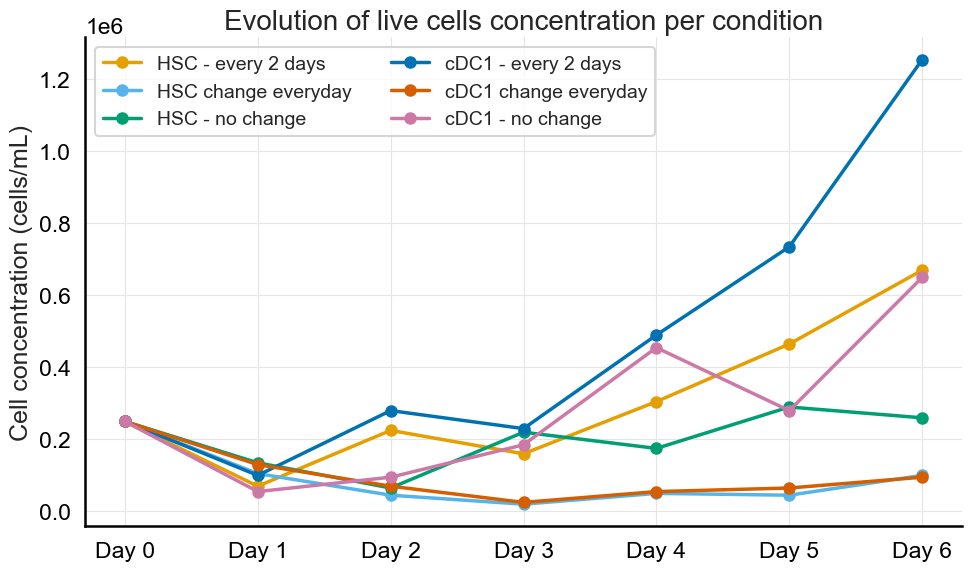

In [34]:
# Plot the concentration of cells in each sample each day
plt.figure(figsize=(10, 6))

for condition in live_cells["Condition"].unique():
    condition_data = live_cells[live_cells["Condition"] == condition]
    plt.plot(condition_data["Day"], condition_data["Concentration (cells/mL)"], marker='o', label=condition)

plt.title("Evolution of live cells concentration per condition")
plt.ylabel("Cell concentration (cells/mL)")

plt.legend(title="", frameon=True, ncol=2)
plt.tight_layout()
plt.savefig("Figures/assessing_viability/cellconcentration");